Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow fastparquet numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
from datetime import datetime

LOG_PATH = Path("experiment_log.csv")

def log_experiment(
    exp_id,
    model,
    features,
    train_window,
    validation_scheme,
    postprocess,
    valid_metric,
    valid_wape,
    valid_rbias,
    public_score="",
    submission_file="",
    notes=""
):
    row = pd.DataFrame([{
        "exp_id": exp_id,
        "date_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model,
        "features": features,
        "train_window": train_window,
        "validation_scheme": validation_scheme,
        "postprocess": postprocess,
        "valid_metric": valid_metric,
        "valid_wape": valid_wape,
        "valid_rbias": valid_rbias,
        "public_score": public_score,
        "submission_file": submission_file,
        "notes": notes,
    }])

    if LOG_PATH.exists():
        log_df = pd.read_csv(LOG_PATH)
        log_df = pd.concat([log_df, row], ignore_index=True)
    else:
        log_df = row

    log_df.to_csv(LOG_PATH, index=False)
    return log_df.tail(5)

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "solo"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path": "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]


## Загрузка данных


In [4]:
train_df = pd.read_parquet(CONFIG["train_path"], engine='fastparquet')
test_df = pd.read_parquet(CONFIG["test_path"], engine='fastparquet')

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: solo
train shape: (4630000, 9)
test shape: (8000, 3)


In [70]:
display(train_df.head())
display(test_df.head())

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
0,0,2025-07-28 00:00:00,13,13,7,58053,136443,97,87359,182291.0,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0
1,0,2025-07-28 00:30:00,6,18,13,58867,134643,95,182291,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0
2,0,2025-07-28 01:00:00,7,8,27,54848,135534,96,271432,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0
3,0,2025-07-28 01:30:00,7,8,5,53086,136497,100,169736,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0
4,0,2025-07-28 02:00:00,1,6,0,57561,135314,101,38880,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0,99590.0


,id,route_id,timestamp
0,3920,0,2025-11-01 11:00:00
1,3921,0,2025-11-01 11:30:00
2,3922,0,2025-11-01 12:00:00
3,3923,0,2025-11-01 12:30:00
4,3924,0,2025-11-01 13:00:00
5,3925,0,2025-11-01 13:30:00
6,3926,0,2025-11-01 14:00:00
7,3927,0,2025-11-01 14:30:00
8,5072,1,2025-11-01 11:00:00
9,5073,1,2025-11-01 11:30:00


In [6]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())

Train date range: 2025-07-28 00:00:00 -> 2025-11-01 10:30:00
Test date range: 2025-11-01 11:00:00 -> 2025-11-01 14:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [7]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4630
status_1,int64,0,0.0,272
status_2,int64,0,0.0,243
status_3,int64,0,0.0,260
status_4,int64,0,0.0,315655
status_5,int64,0,0.0,1463128
status_6,int64,0,0.0,82051
target_1h,int64,0,0.0,692648


In [8]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']
Target column: target_1h
Forecast points: 8


## Распределения


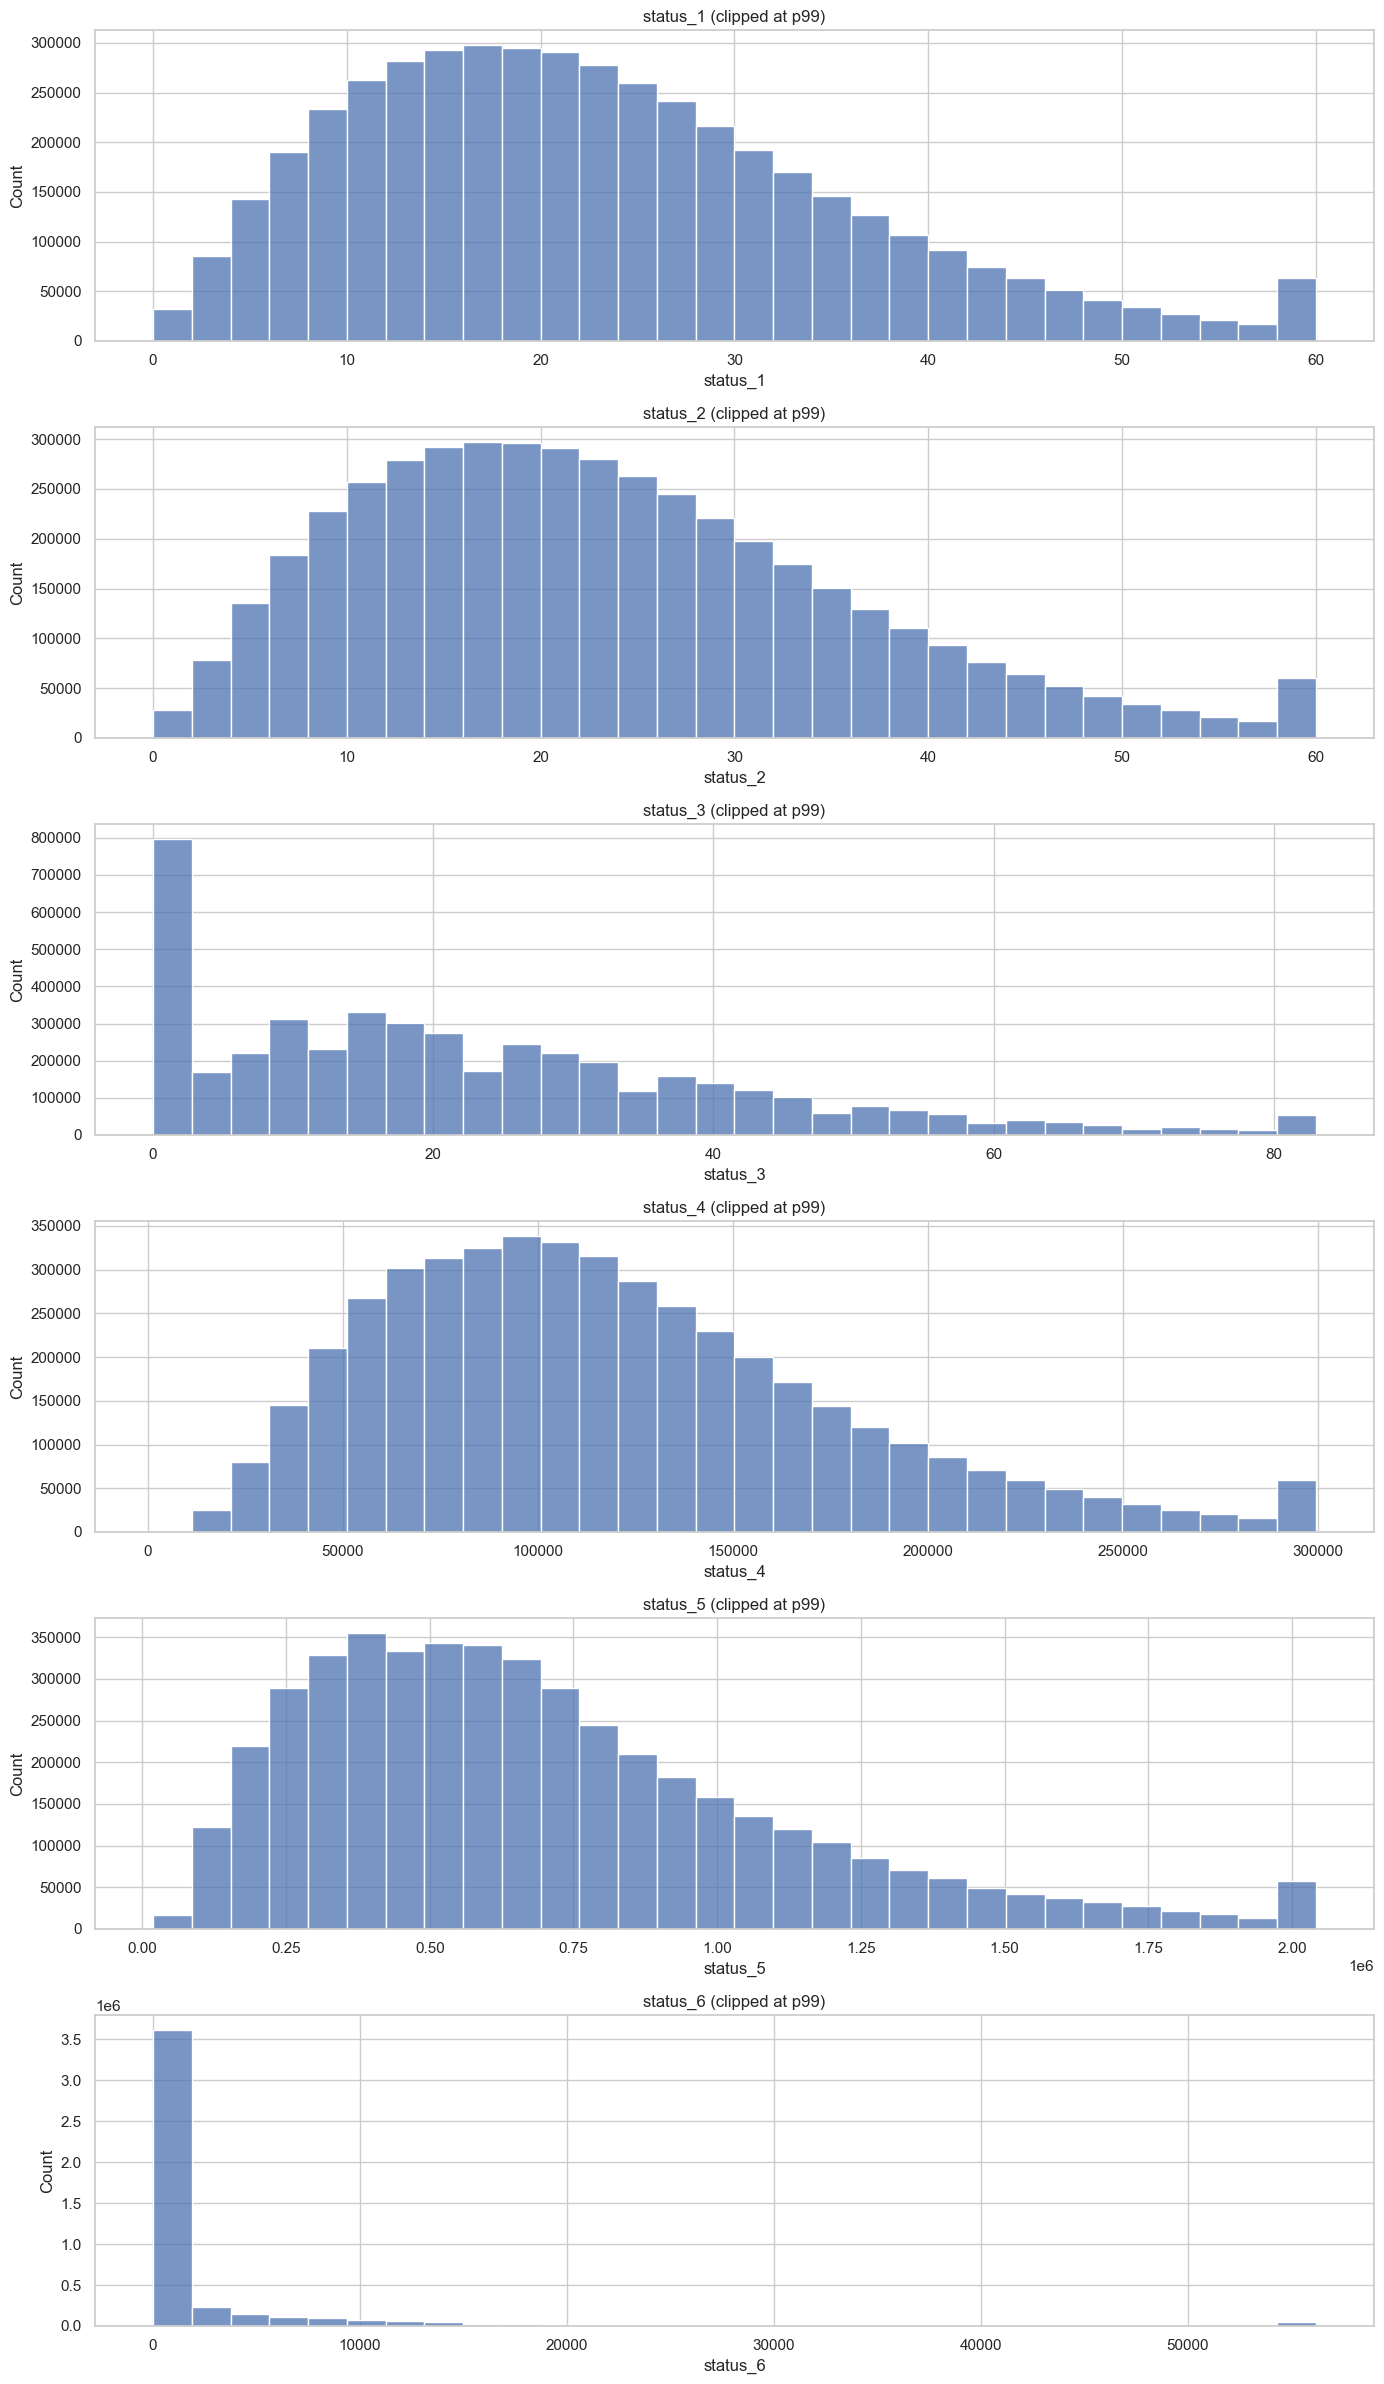

In [9]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


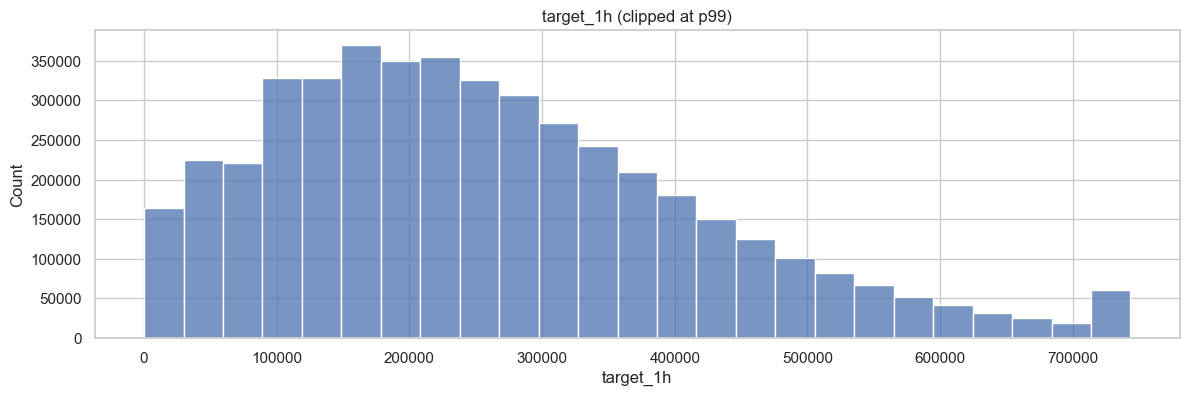

In [10]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## Генерируем будущие таргеты


In [11]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)

,route_id,timestamp,target_1h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
0,0,2025-07-28 00:00:00,87359,182291.0,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0
1,0,2025-07-28 00:30:00,182291,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0
2,0,2025-07-28 01:00:00,271432,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0
3,0,2025-07-28 01:30:00,169736,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0
4,0,2025-07-28 02:00:00,38880,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0,99590.0
5,0,2025-07-28 02:30:00,134137,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0,99590.0,138470.0
6,0,2025-07-28 03:00:00,134137,77760.0,77760.0,76829.0,193469.0,194401.0,99590.0,138470.0,116641.0
7,0,2025-07-28 03:30:00,77760,77760.0,76829.0,193469.0,194401.0,99590.0,138470.0,116641.0,38880.0
8,0,2025-07-28 04:00:00,77760,76829.0,193469.0,194401.0,99590.0,138470.0,116641.0,38880.0,38880.0
9,0,2025-07-28 04:30:00,76829,193469.0,194401.0,99590.0,138470.0,116641.0,38880.0,38880.0,77760.0


In [12]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)

Rows with future targets: (4622000, 17)


## Корреляции


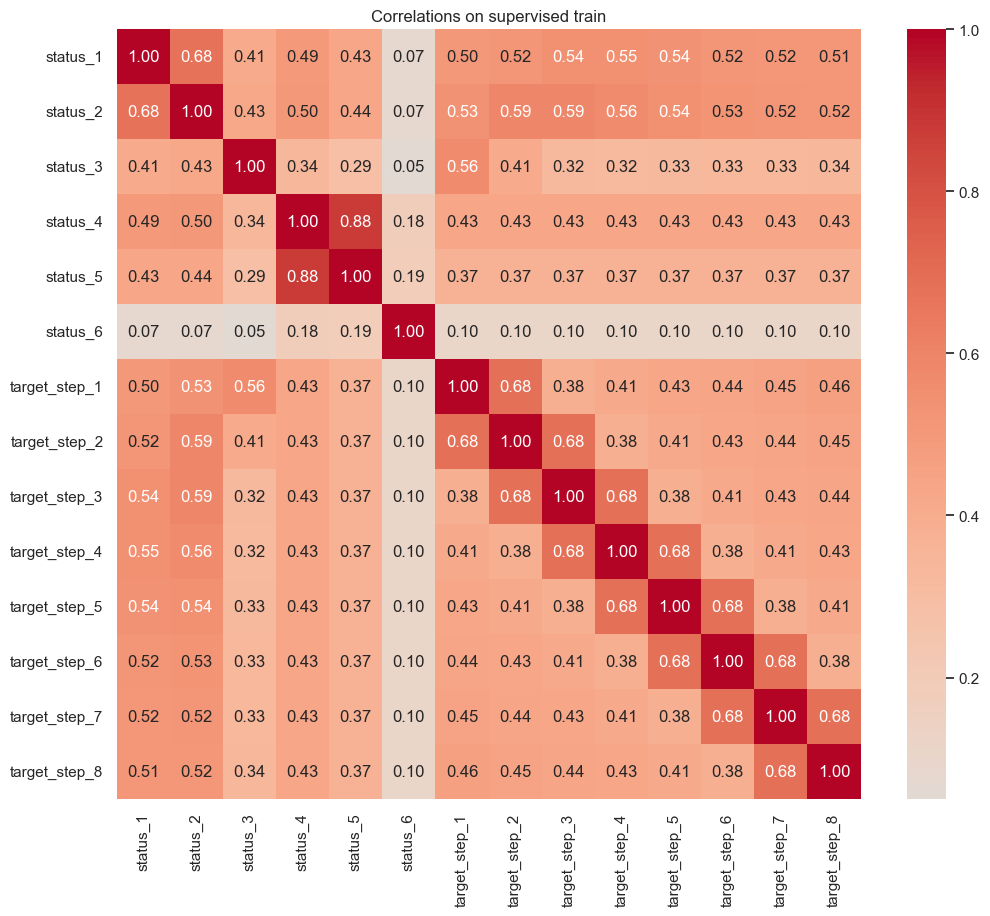

In [13]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [14]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)        


Feature columns: ['route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']


In [15]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (673000, 16)


In [16]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 17)


## Time-based split


In [17]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (539000, 16)
Valid rows: (134000, 16)


In [44]:
print("FIT:",
      fit_df["source_timestamp"].min(),
      "->",
      fit_df["source_timestamp"].max())

print("VALID:",
      valid_df["source_timestamp"].min(),
      "->",
      valid_df["source_timestamp"].max())

FIT: 2025-10-18 06:30:00 -> 2025-10-29 11:30:00
VALID: 2025-10-29 12:00:00 -> 2025-11-01 06:30:00


In [45]:
print("Split point:", split_point)

Split point: 2025-10-29 11:30:00


In [46]:
print("fit rows:", len(fit_df))
print("valid rows:", len(valid_df))
print("fit share:", len(fit_df) / len(train_model_df))
print("valid share:", len(valid_df) / len(train_model_df))

fit rows: 539000
valid rows: 134000
fit share: 0.8008915304606241
valid share: 0.19910846953937592


In [47]:
print("fit routes:", fit_df["route_id"].nunique())
print("valid routes:", valid_df["route_id"].nunique())

fit routes: 1000
valid routes: 1000


In [48]:
assert fit_df["source_timestamp"].max() <= valid_df["source_timestamp"].min()

In [18]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## Линейный baseline


In [19]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']


In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)


In [21]:
model.fit(X_fit, y_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [22]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
3875168,203323.254305,204473.440966,194895.584613,185368.436429,182346.182617,182772.106587,182621.218666,181608.451620
861038,707506.261565,734883.358398,656422.483095,574407.669946,534124.113943,515415.013509,497990.505741,482290.855590
2203738,108947.751430,80810.517813,71360.187837,77561.493019,77598.042928,75048.611150,74263.962590,74061.889009
1361078,468659.241338,410150.971312,359605.379875,349219.995346,349081.978456,349994.477815,349763.210787,350168.497630
1962978,477407.585253,399553.785059,369748.211008,387814.424862,405477.892991,417308.255205,426756.506018,435629.052327


## Метрики


In [37]:
from metrics import metric_components, metric_by_horizon

print('Метрики на fit (по горизонтам):')
display(metric_by_horizon(y_fit, fit_pred_df).round(3))

fit_scores = metric_components(
    y_fit.to_numpy().flatten(),
    fit_pred_df.to_numpy().flatten()
)

print('Общая метрика на fit:')
print(f"{fit_scores['metric']:.3f}")
print(f"WAPE: {fit_scores['wape']:.3f}")
print(f"Rbias: {fit_scores['rbias']:.3f}")

Метрики на fit (по горизонтам):


,horizon,wape,rbias,metric
0,step_1,0.320,0.0,0.320
1,step_2,0.337,0.0,0.337
2,step_3,0.340,0.0,0.340
3,step_4,0.344,0.0,0.344
4,step_5,0.347,0.0,0.347
5,step_6,0.348,0.0,0.348
6,step_7,0.348,0.0,0.348
7,step_8,0.349,0.0,0.349


Общая метрика на fit:
0.342
WAPE: 0.342
Rbias: 0.000


In [39]:
print('Метрики на valid (по горизонтам):')
display(metric_by_horizon(y_valid, valid_pred_df).round(3))

valid_scores = metric_components(
    y_valid.to_numpy().flatten(),
    valid_pred_df.to_numpy().flatten()
)

print('Общая метрика на valid:')
print(f"{valid_scores['metric']:.3f}")
print(f"WAPE: {valid_scores['wape']:.3f}")
print(f"Rbias: {valid_scores['rbias']:.3f}")

Метрики на valid (по горизонтам):


,horizon,wape,rbias,metric
0,step_1,0.316,0.005,0.321
1,step_2,0.335,0.005,0.340
2,step_3,0.338,0.007,0.344
3,step_4,0.342,0.007,0.349
4,step_5,0.345,0.007,0.352
5,step_6,0.347,0.005,0.353
6,step_7,0.348,0.004,0.352
7,step_8,0.348,0.003,0.352


Общая метрика на valid:
0.345
WAPE: 0.340
Rbias: 0.005


## Конвертируем прогноз в нужный формат 


In [33]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [34]:
forecast_df.head()

,id,y_pred
0,3920,153053.512277
1,3921,172304.459924
2,3922,182275.280419
3,3923,180017.072013
4,3924,176280.811637


In [35]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [36]:
submission_path =  f"submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: submission_solo.csv


In [43]:
log_experiment(
    exp_id="exp_000",
    model="ridge",
    features="route_id + status_*",
    train_window="14d",
    validation_scheme="time_split_80_20_recent_14d",
    postprocess="none",
    valid_metric=valid_scores["metric"],
    valid_wape=valid_scores["wape"],
    valid_rbias=valid_scores["rbias"],
    submission_file="sub_exp_000.csv",
    public_score=0.382,
    notes="baseline notebook: Ridge(alpha=4.0), OHE(route_id), scaler+imputer, multi-step direct forecast"
)

,exp_id,date_time,model,features,train_window,validation_scheme,postprocess,valid_metric,valid_wape,valid_rbias,public_score,submission_file,notes
0,exp_000,2026-04-06 15:52:34,ridge,route_id + status_*,14d,time_split_80_20_recent_14d,none,0.345468,0.340022,0.005446,0.382,sub_exp_000.csv,"baseline notebook: Ridge(alpha=4.0), OHE(route..."


### holdout validation

In [65]:
# Origin-based holdout: имитация реального теста
# Предполагается, что у тебя уже есть:
# - train_model_df
# - FUTURE_TARGET_COLS
# - feature_cols
# - FORECAST_POINTS
# - колонка source_timestamp

STEP_MINUTES = 30
HORIZON = FORECAST_POINTS
STEP = pd.Timedelta(minutes=STEP_MINUTES)

# 1) Последний момент, который может быть "точкой прогноза",
#    чтобы следующие HORIZON шагов ещё существовали в train
origin_ts = train_model_df["source_timestamp"].max() - HORIZON * STEP

# 2) VALID: строки ровно в момент origin_ts
valid_df = train_model_df[
    train_model_df["source_timestamp"] == origin_ts
].copy()

# 3) FIT: только те строки, у которых весь прогнозный горизонт
#    заканчивается не позже origin_ts
#    То есть source_timestamp + HORIZON*STEP <= origin_ts
fit_cutoff = origin_ts - HORIZON * STEP

fit_df = train_model_df[
    train_model_df["source_timestamp"] <= fit_cutoff
].copy()

print("=== Origin-based holdout ===")
print("train_model_df range:",
      train_model_df["source_timestamp"].min(),
      "->",
      train_model_df["source_timestamp"].max())

print("origin_ts:", origin_ts)
print("fit_cutoff:", fit_cutoff)

print("\nFIT:")
print(" range:", fit_df["source_timestamp"].min(), "->", fit_df["source_timestamp"].max())
print(" rows:", len(fit_df))
print(" routes:", fit_df["route_id"].nunique())

print("\nVALID:")
print(" timestamp:", origin_ts)
print(" rows:", len(valid_df))
print(" routes:", valid_df["route_id"].nunique())

# 4) Sanity checks
assert len(valid_df) > 0, "VALID пустой: возможно, такого timestamp нет в train_model_df"
assert len(fit_df) > 0, "FIT пустой: слишком маленькая история после обрезки"

# train не должен залезать в будущее относительно valid-origin
assert fit_df["source_timestamp"].max() <= fit_cutoff

# valid должен быть ровно в одной точке времени
assert valid_df["source_timestamp"].nunique() == 1
assert valid_df["source_timestamp"].iloc[0] == origin_ts

# 5) Готовые X / y
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

print("\nX_fit:", X_fit.shape, "y_fit:", y_fit.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)

=== Origin-based holdout ===
train_model_df range: 2025-10-18 06:30:00 -> 2025-11-01 06:30:00
origin_ts: 2025-11-01 02:30:00
fit_cutoff: 2025-10-31 22:30:00

FIT:
 range: 2025-10-18 06:30:00 -> 2025-10-31 22:30:00
 rows: 657000
 routes: 1000

VALID:
 timestamp: 2025-11-01 02:30:00
 rows: 1000
 routes: 1000

X_fit: (657000, 7) y_fit: (657000, 8)
X_valid: (1000, 7) y_valid: (1000, 8)


In [66]:
model.fit(X_fit, y_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [67]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
2375173,173701.942027,145208.632868,124720.768603,122345.600753,123484.899060,125099.122760,126153.128862,127132.751489
2620563,522416.911489,368742.243534,309744.831952,341923.415232,367045.922957,381077.023668,392571.917945,403527.010315
1500103,334155.418934,326013.840244,319024.963186,317900.811733,318959.334694,320325.129013,321548.401235,322248.763957
2680753,379679.795135,320082.247009,305340.925833,325297.635691,340190.940850,348865.109253,355538.530391,361616.529145
2319613,279150.131731,301006.459084,309463.686452,304531.328039,296874.075038,290617.555924,286213.634360,282162.955739


In [68]:
from metrics import metric_components, metric_by_horizon

print('Метрики на fit (по горизонтам):')
display(metric_by_horizon(y_fit, fit_pred_df).round(3))

fit_scores = metric_components(
    y_fit.to_numpy().flatten(),
    fit_pred_df.to_numpy().flatten()
)

print('Общая метрика на fit:')
print(f"{fit_scores['metric']:.3f}")
print(f"WAPE: {fit_scores['wape']:.3f}")
print(f"Rbias: {fit_scores['rbias']:.3f}")

Метрики на fit (по горизонтам):


,horizon,wape,rbias,metric
0,step_1,0.319,0.0,0.319
1,step_2,0.337,0.0,0.337
2,step_3,0.339,0.0,0.339
3,step_4,0.343,0.0,0.343
4,step_5,0.346,0.0,0.346
5,step_6,0.347,0.0,0.347
6,step_7,0.348,0.0,0.348
7,step_8,0.348,0.0,0.348


Общая метрика на fit:
0.341
WAPE: 0.341
Rbias: 0.000


In [69]:
print('Метрики на valid (по горизонтам):')
display(metric_by_horizon(y_valid, valid_pred_df).round(3))

valid_scores = metric_components(
    y_valid.to_numpy().flatten(),
    valid_pred_df.to_numpy().flatten()
)

print('Общая метрика на valid:')
print(f"{valid_scores['metric']:.3f}")
print(f"WAPE: {valid_scores['wape']:.3f}")
print(f"Rbias: {valid_scores['rbias']:.3f}")

Метрики на valid (по горизонтам):


,horizon,wape,rbias,metric
0,step_1,0.303,0.013,0.316
1,step_2,0.345,0.017,0.362
2,step_3,0.342,0.022,0.365
3,step_4,0.335,0.002,0.336
4,step_5,0.348,0.022,0.370
5,step_6,0.347,0.023,0.371
6,step_7,0.352,0.021,0.373
7,step_8,0.360,0.031,0.392


Общая метрика на valid:
0.360
WAPE: 0.342
Rbias: 0.019
